<a href="https://colab.research.google.com/github/vanshjolly/lichess_data_analysis_eda/blob/main/lichess_data_analysis.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns


In [ ]:
df = pd.read_csv('/content/games.csv')
df.head()

,id,rated,created_at,last_move_at,turns,victory_status,winner,increment_code,white_id,white_rating,black_id,black_rating,moves,opening_eco,opening_name,opening_ply
0,TZJHLljE,False,1.504210e+12,1.504210e+12,13,outoftime,white,15+2,bourgris,1500,a-00,1191,d4 d5 c4 c6 cxd5 e6 dxe6 fxe6 Nf3 Bb4+ Nc3 Ba5...,D10,Slav Defense: Exchange Variation,5
1,l1NXvwaE,True,1.504130e+12,1.504130e+12,16,resign,black,5+10,a-00,1322,skinnerua,1261,d4 Nc6 e4 e5 f4 f6 dxe5 fxe5 fxe5 Nxe5 Qd4 Nc6...,B00,Nimzowitsch Defense: Kennedy Variation,4
2,mIICvQHh,True,1.504130e+12,1.504130e+12,61,mate,white,5+10,ischia,1496,a-00,1500,e4 e5 d3 d6 Be3 c6 Be2 b5 Nd2 a5 a4 c5 axb5 Nc...,C20,King's Pawn Game: Leonardis Variation,3
3,kWKvrqYL,True,1.504110e+12,1.504110e+12,61,mate,white,20+0,daniamurashov,1439,adivanov2009,1454,d4 d5 Nf3 Bf5 Nc3 Nf6 Bf4 Ng4 e3 Nc6 Be2 Qd7 O...,D02,Queen's Pawn Game: Zukertort Variation,3
4,9tXo1AUZ,True,1.504030e+12,1.504030e+12,95,mate,white,30+3,nik221107,1523,adivanov2009,1469,e4 e5 Nf3 d6 d4 Nc6 d5 Nb4 a3 Na6 Nc3 Be7 b4 N...,C41,Philidor Defense,5


In [ ]:
df.shape

(20058, 16)

In [ ]:
df.columns

Index(['id', 'rated', 'created_at', 'last_move_at', 'turns', 'victory_status',
       'winner', 'increment_code', 'white_id', 'white_rating', 'black_id',
       'black_rating', 'moves', 'opening_eco', 'opening_name', 'opening_ply'],
      dtype='object')

In [ ]:
df.describe


<bound method NDFrame.describe of              id  rated    created_at  last_move_at  turns victory_status  \
0      TZJHLljE  False  1.504210e+12  1.504210e+12     13      outoftime   
1      l1NXvwaE   True  1.504130e+12  1.504130e+12     16         resign   
2      mIICvQHh   True  1.504130e+12  1.504130e+12     61           mate   
3      kWKvrqYL   True  1.504110e+12  1.504110e+12     61           mate   
4      9tXo1AUZ   True  1.504030e+12  1.504030e+12     95           mate   
...         ...    ...           ...           ...    ...            ...   
20053  EfqH7VVH   True  1.499791e+12  1.499791e+12     24         resign   
20054  WSJDhbPl   True  1.499698e+12  1.499699e+12     82           mate   
20055  yrAas0Kj   True  1.499698e+12  1.499698e+12     35           mate   
20056  b0v4tRyF   True  1.499696e+12  1.499697e+12    109         resign   
20057  N8G2JHGG   True  1.499643e+12  1.499644e+12     78           mate   

      winner increment_code       white_id  white_rating            black_id  \
0      white           15+2       bourgris          1500                a-00   
1      black           5+10           a-00          1322           skinnerua   
2      white           5+10         ischia          1496                a-00   
3      white           20+0  daniamurashov          1439        adivanov2009   
4      white           30+3      nik221107          1523        adivanov2009   
...      ...            ...            ...           ...                 ...   
20053  white          10+10        belcolt          1691            jamboger   
20054  black           10+0       jamboger          1233  farrukhasomiddinov   
20055  white           10+0       jamboger          1219        schaaksmurf3   
20056  white           10+0   marcodisogno          1360            jamboger   
20057  black           10+0       jamboger          1235               ffbob   

       black_rating                                              moves  \
0              1191  d4 d5 c4 c6 cxd5 e6 dxe6 fxe6 Nf3 Bb4+ Nc3 Ba5...   
1              1261  d4 Nc6 e4 e5 f4 f6 dxe5 fxe5 fxe5 Nxe5 Qd4 Nc6...   
2              1500  e4 e5 d3 d6 Be3 c6 Be2 b5 Nd2 a5 a4 c5 axb5 Nc...   
3              1454  d4 d5 Nf3 Bf5 Nc3 Nf6 Bf4 Ng4 e3 Nc6 Be2 Qd7 O...   
4              1469  e4 e5 Nf3 d6 d4 Nc6 d5 Nb4 a3 Na6 Nc3 Be7 b4 N...   
...             ...                                                ...   
20053          1220  d4 f5 e3 e6 Nf3 Nf6 Nc3 b6 Be2 Bb7 O-O Be7 Ne5...   
20054          1196  d4 d6 Bf4 e5 Bg3 Nf6 e3 exd4 exd4 d5 c3 Bd6 Bd...   
20055          1286  d4 d5 Bf4 Nc6 e3 Nf6 c3 e6 Nf3 Be7 Bd3 O-O Nbd...   
20056          1227  e4 d6 d4 Nf6 e5 dxe5 dxe5 Qxd1+ Kxd1 Nd5 c4 Nb...   
20057          1339  d4 d5 Bf4 Na6 e3 e6 c3 Nf6 Nf3 Bd7 Nbd2 b5 Bd3...   

      opening_eco                            opening_name  opening_ply  
0             D10        Slav Defense: Exchange Variation            5  
1             B00  Nimzowitsch Defense: Kennedy Variation            4  
2             C20   King's Pawn Game: Leonardis Variation            3  
3             D02  Queen's Pawn Game: Zukertort Variation            3  
4             C41                        Philidor Defense            5  
...           ...                                     ...          ...  
20053         A80                           Dutch Defense            2  
20054         A41                            Queen's Pawn            2  
20055         D00         Queen's Pawn Game: Mason Attack            3  
20056         B07                            Pirc Defense            4  
20057         D00         Queen's Pawn Game: Mason Attack            3  

[20058 rows x 16 columns]>

In [ ]:
df.info

<bound method DataFrame.info of              id  rated    created_at  last_move_at  turns victory_status  \
0      TZJHLljE  False  1.504210e+12  1.504210e+12     13      outoftime   
1      l1NXvwaE   True  1.504130e+12  1.504130e+12     16         resign   
2      mIICvQHh   True  1.504130e+12  1.504130e+12     61           mate   
3      kWKvrqYL   True  1.504110e+12  1.504110e+12     61           mate   
4      9tXo1AUZ   True  1.504030e+12  1.504030e+12     95           mate   
...         ...    ...           ...           ...    ...            ...   
20053  EfqH7VVH   True  1.499791e+12  1.499791e+12     24         resign   
20054  WSJDhbPl   True  1.499698e+12  1.499699e+12     82           mate   
20055  yrAas0Kj   True  1.499698e+12  1.499698e+12     35           mate   
20056  b0v4tRyF   True  1.499696e+12  1.499697e+12    109         resign   
20057  N8G2JHGG   True  1.499643e+12  1.499644e+12     78           mate   

      winner increment_code       white_id  white_rating            black_id  \
0      white           15+2       bourgris          1500                a-00   
1      black           5+10           a-00          1322           skinnerua   
2      white           5+10         ischia          1496                a-00   
3      white           20+0  daniamurashov          1439        adivanov2009   
4      white           30+3      nik221107          1523        adivanov2009   
...      ...            ...            ...           ...                 ...   
20053  white          10+10        belcolt          1691            jamboger   
20054  black           10+0       jamboger          1233  farrukhasomiddinov   
20055  white           10+0       jamboger          1219        schaaksmurf3   
20056  white           10+0   marcodisogno          1360            jamboger   
20057  black           10+0       jamboger          1235               ffbob   

       black_rating                                              moves  \
0              1191  d4 d5 c4 c6 cxd5 e6 dxe6 fxe6 Nf3 Bb4+ Nc3 Ba5...   
1              1261  d4 Nc6 e4 e5 f4 f6 dxe5 fxe5 fxe5 Nxe5 Qd4 Nc6...   
2              1500  e4 e5 d3 d6 Be3 c6 Be2 b5 Nd2 a5 a4 c5 axb5 Nc...   
3              1454  d4 d5 Nf3 Bf5 Nc3 Nf6 Bf4 Ng4 e3 Nc6 Be2 Qd7 O...   
4              1469  e4 e5 Nf3 d6 d4 Nc6 d5 Nb4 a3 Na6 Nc3 Be7 b4 N...   
...             ...                                                ...   
20053          1220  d4 f5 e3 e6 Nf3 Nf6 Nc3 b6 Be2 Bb7 O-O Be7 Ne5...   
20054          1196  d4 d6 Bf4 e5 Bg3 Nf6 e3 exd4 exd4 d5 c3 Bd6 Bd...   
20055          1286  d4 d5 Bf4 Nc6 e3 Nf6 c3 e6 Nf3 Be7 Bd3 O-O Nbd...   
20056          1227  e4 d6 d4 Nf6 e5 dxe5 dxe5 Qxd1+ Kxd1 Nd5 c4 Nb...   
20057          1339  d4 d5 Bf4 Na6 e3 e6 c3 Nf6 Nf3 Bd7 Nbd2 b5 Bd3...   

      opening_eco                            opening_name  opening_ply  
0             D10        Slav Defense: Exchange Variation            5  
1             B00  Nimzowitsch Defense: Kennedy Variation            4  
2             C20   King's Pawn Game: Leonardis Variation            3  
3             D02  Queen's Pawn Game: Zukertort Variation            3  
4             C41                        Philidor Defense            5  
...           ...                                     ...          ...  
20053         A80                           Dutch Defense            2  
20054         A41                            Queen's Pawn            2  
20055         D00         Queen's Pawn Game: Mason Attack            3  
20056         B07                            Pirc Defense            4  
20057         D00         Queen's Pawn Game: Mason Attack            3  

[20058 rows x 16 columns]>

In [ ]:
df.isnull().sum()

,0
id,0
rated,0
created_at,0
last_move_at,0
turns,0
victory_status,0
winner,0
increment_code,0
white_id,0
white_rating,0


In [ ]:
df.duplicated().sum()

np.int64(429)

In [ ]:
df.drop_duplicates(inplace=True)

In [ ]:
df.duplicated().sum()

np.int64(0)

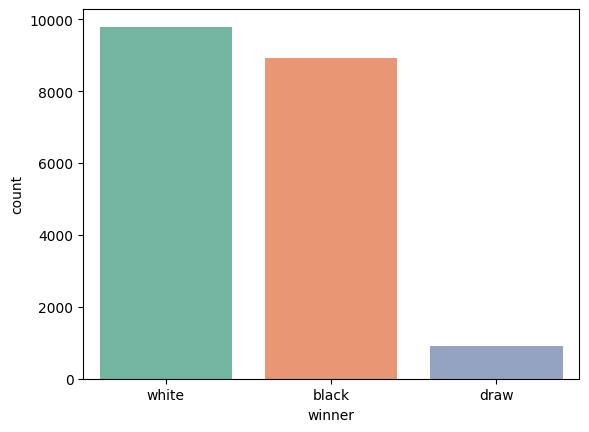

In [49]:
ax = sns.countplot(
    data=df,
    x='winner',
    hue='winner',
    palette='Set2',
    legend=False
)

# **Chart 1: Winner Distribution**

*   **Why this chart is used?**

A count plot is used to visualize the frequency of each game outcome (White win, Black win, or Draw). It provides a quick overview of the distribution of winners in the dataset and helps identify any imbalance in game results.
*   **Insights Found**

White wins are slightly more frequent than Black wins.
Draws occur much less frequently compared to wins.
The results suggest a possible first-move advantage for White players.

*   **Positive Business Impact**
Chess platforms can develop tutorials focused on improving Black's defensive strategies.
Match organizers can analyze whether the first-move advantage affects tournament fairness.
Coaches can use this information to train beginners in opening principles and first-move strategies.

* **Negative Business Impact**
A consistently higher White win rate may discourage players from choosing Black.
If the imbalance becomes significant, players may perceive the platform as unfair, reducing engagement.





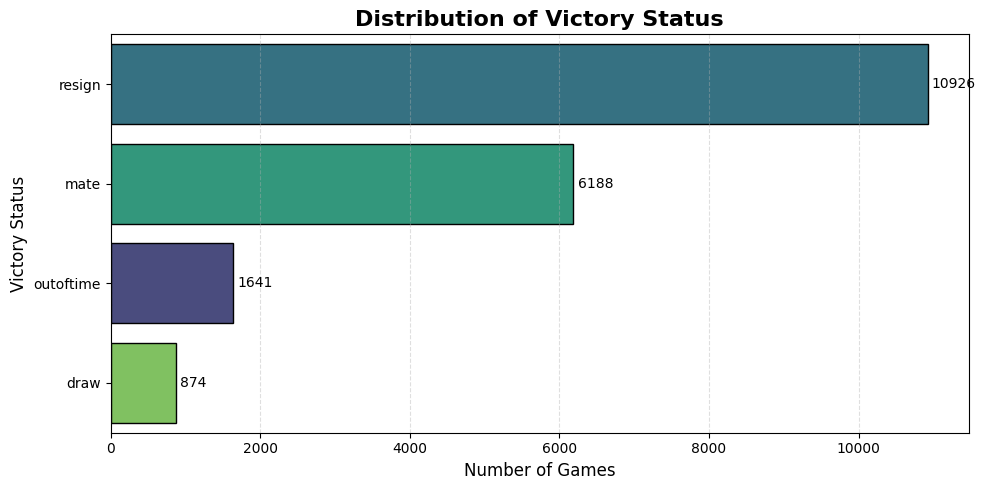

In [ ]:
plt.figure(figsize=(10, 5))

order = df['victory_status'].value_counts().index # Get the victory status categories sorted by their frequency (highest to lowest)

ax = sns.countplot(
    data=df,
    y='victory_status',
    order=order,
    hue='victory_status',
    palette='viridis',
    edgecolor='black',
    legend=False
)

plt.title("Distribution of Victory Status", fontsize=16, fontweight='bold')
plt.xlabel("Number of Games", fontsize=12)
plt.ylabel("Victory Status", fontsize=12)


for container in ax.containers: # Add the count value at the end of each bar
    ax.bar_label(container, padding=3)

plt.grid(axis='x', linestyle='--', alpha=0.4)
plt.tight_layout() # Automatically adjust spacing to prevent overlapping elements
plt.show()

#   **Chart 2: Victory Status Distribution**

*   **Why this chart is used?**

This chart helps understand the different ways games conclude, such as checkmate, resignation, timeout, or draw. It highlights player behavior and common game-ending patterns.
*   **Insights found**

Most games end through checkmate or resignation.
Timeouts and draws occur less frequently.
Players generally prefer resigning instead of playing until checkmate when they are in a losing position.

*   **Positive Business Impact**

Developers can improve endgame learning modules based on common game-ending methods.
Chess platforms can design features encouraging players to complete games rather than resign early.
Tournament organizers can evaluate whether time controls are appropriate.
*   **Negative Business Impact**

A high number of timeout games may indicate poor time management or unsuitable time controls.
Frequent resignations may reduce opportunities for players to practice endgame techniques.





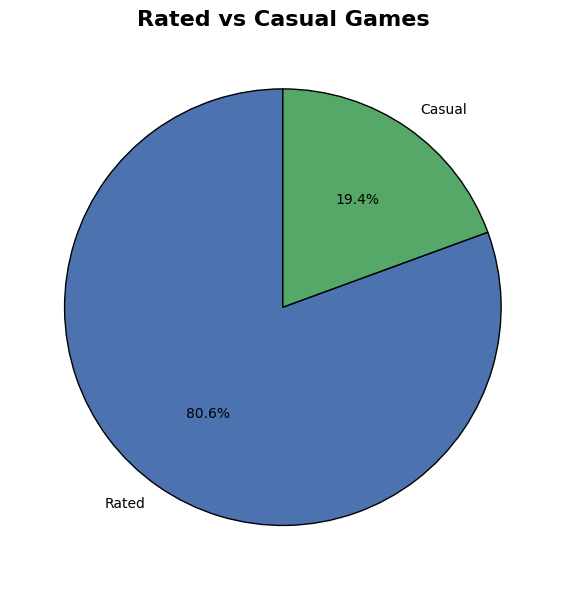

In [ ]:
rated = df['rated'].value_counts()  #Count the number of Rated  Casual games

plt.figure(figsize=(6,6))

plt.pie(         # Create a pie chart to show the proportion of Rated and Casual games
    rated,
    labels=['Rated','Casual'],
    autopct='%1.1f%%',
    startangle=90,
    colors=['#4C72B0','#55A868'],
    wedgeprops={'edgecolor':'black'}
)

plt.title("Rated vs Casual Games", fontsize=16, weight='bold')

plt.tight_layout()
plt.show()

# **# Chart 3: Rated vs Casual Games**

*   This pie chart compares the proportion of rated and casual games, helping understand whether users primarily play competitively or recreationally.

*  **Insights Found**

The chart shows the percentage of competitive and casual games.
It reveals the overall playing preference of users on the platform.
It helps identify whether ranking features are widely used.


*   **Positive Business Impact**

If rated games dominate, the platform can introduce more tournaments, leaderboards, and competitive events.
If casual games are more common, beginner-friendly features and social gameplay can be prioritized.
Marketing campaigns can be designed according to user preferences.

*    **Negative Business Impact**

Heavy dependence on one game type may reduce engagement for users preferring the other mode.
Casual players may feel discouraged if the platform focuses mainly on competitive gameplay.





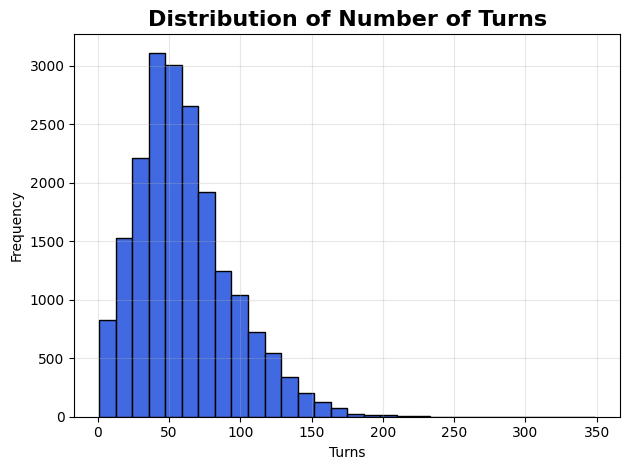

In [ ]:
plt.hist(     #Create a histogram to visualize the distribution of the number of turns played in each game
    df['turns'],
    bins=30,
    color='royalblue',
    edgecolor='black'
)

plt.title("Distribution of Number of Turns", fontsize=16, weight='bold')
plt.xlabel("Turns")
plt.ylabel("Frequency")

plt.grid(alpha=0.3)    #Add light grid lines to improve readability

plt.tight_layout()
plt.show()

# **Chart 4: Distribution of Number of Turns**

*   A histogram is ideal for understanding how long chess games usually last. It helps identify common game durations and detect unusually short or long matches.

*   **Insights Found**

Most games finish within a moderate number of turns.
Extremely short and extremely long games are relatively uncommon.
The distribution provides an estimate of the average game duration.

*  **Positive Business Impact**

Tournament organizers can estimate average match durations for scheduling purposes.
Server resources can be optimized based on expected game lengths.

* **Negative Business Impact**

A large number of very short games may indicate early resignations, disconnects, or poor matchmaking.
Very long games may reduce user engagement among casual players with limited time.






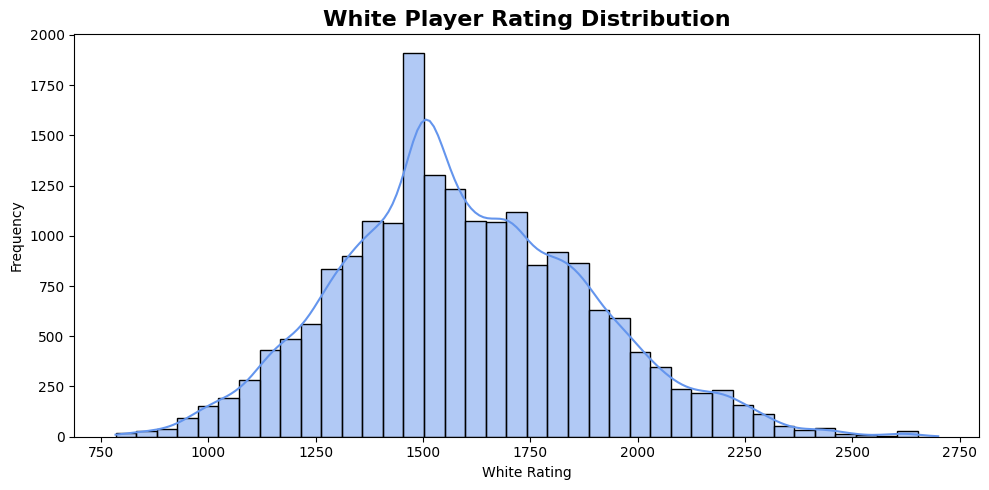

In [ ]:
plt.figure(figsize=(10,5))

sns.histplot(   # Create a histogram to visualize the distribution of White player ratings
    df['white_rating'],
    bins=40,
    kde=True,
    color='cornflowerblue'
)

plt.title("White Player Rating Distribution", fontsize=16, weight='bold')
plt.xlabel("White Rating")
plt.ylabel("Frequency")

plt.tight_layout()
plt.show()

# **Chart 5: White Player Rating Distribution**

*   This histogram helps analyze the distribution of White player ratings. It provides an understanding of the overall skill levels represented in the dataset.

*   **Insights Found**

Most White players belong to the intermediate rating range.
The rating distribution appears approximately bell-shaped, indicating a balanced player population.

*  **Business Impact**

Matchmaking algorithms can be optimized around the largest skill group.
Training content can target the most common player skill level.






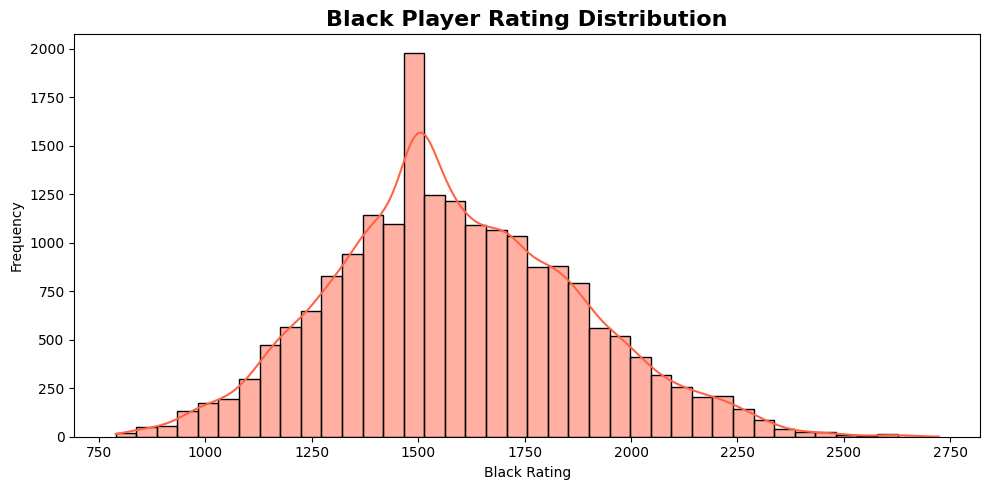

In [50]:
plt.figure(figsize=(10,5))
  # Create a histogram to visualize the distribution of Blackj player ratings
sns.histplot(
    df['black_rating'],
    bins=40,
    kde=True,
    color='tomato'
)

plt.title("Black Player Rating Distribution", fontsize=16, weight='bold')
plt.xlabel("Black Rating")
plt.ylabel("Frequency")

plt.tight_layout()
plt.show()

# **Chart 6: Black Player Rating Distribution**


*   **Insights Found**

Most Black players fall into the intermediate rating range.
Very few players have extremely low or high ratings.
* **Business Impact**

Positive: Helps improve matchmaking and create rating-based tournaments.

Negative: Fewer high-rated players may increase waiting time for advanced players.



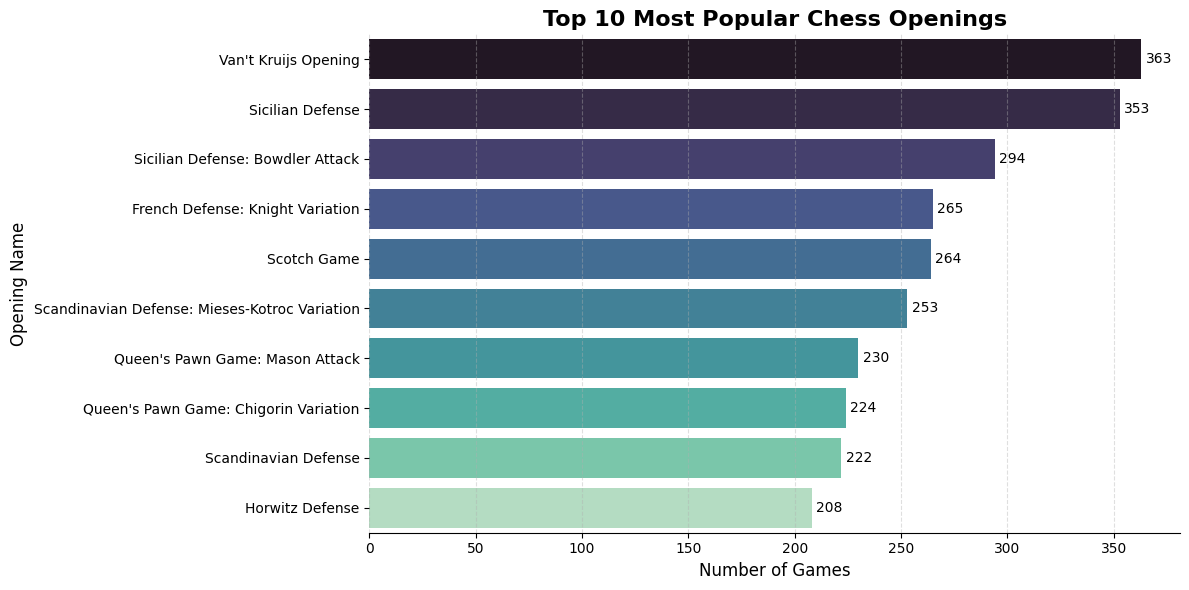

In [ ]:
plt.figure(figsize=(12,6))

top = df['opening_name'].value_counts().head(10)
# Count the frequency of each opening and select the top 10 most played openings

ax = sns.barplot(
    x=top.values,
    y=top.index,
    hue=top.index,          # Required for palette
    palette='mako',
    legend=False
)

plt.title("Top 10 Most Popular Chess Openings", fontsize=16, fontweight='bold')
plt.xlabel("Number of Games", fontsize=12)
plt.ylabel("Opening Name", fontsize=12)

# Add value labels
for container in ax.containers:
    ax.bar_label(container, padding=3)

plt.grid(axis='x', linestyle='--', alpha=0.4)
sns.despine(left=True)

plt.tight_layout()
plt.show()

# **Chart 7: Top 10 Most Popular Chess Openings**

**Insights Found**

A few openings dominate most games.
Players prefer well-known and established openings.

**Business Impact**

Positive: Training content can focus on popular openings.

Negative: Overuse of the same openings may reduce strategic diversity.

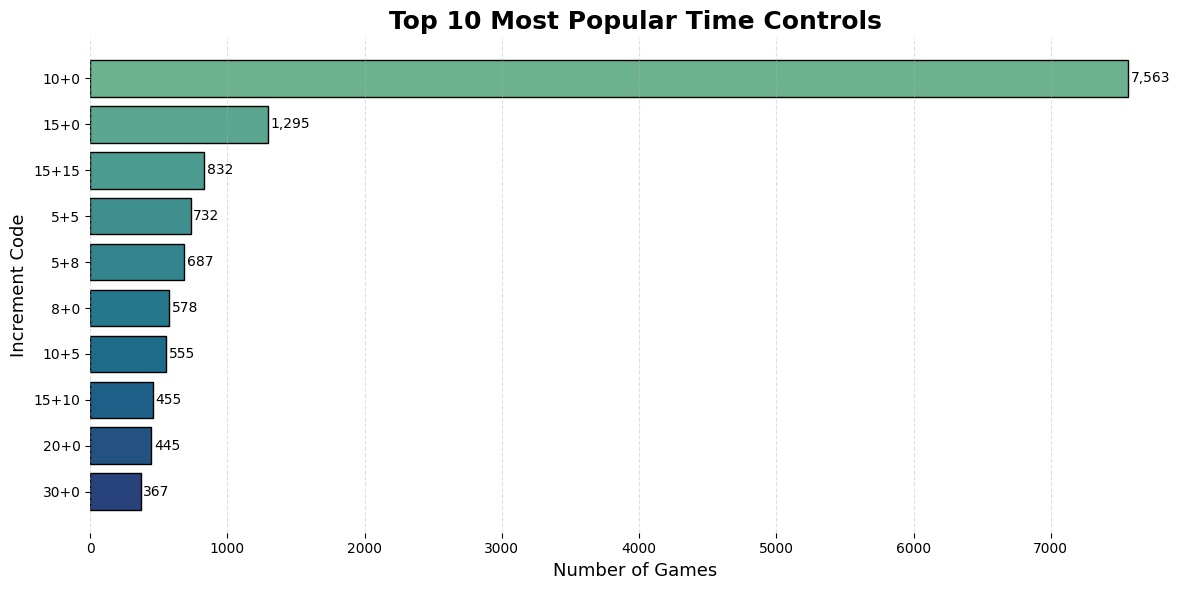

In [ ]:
plt.figure(figsize=(12, 6))

# Top 10 most common time controls
top = df['increment_code'].value_counts().head(10)

# Professional color palette
colors = plt.colormaps['crest'](np.linspace(0.2, 0.9, len(top)))

bars = plt.barh(
    top.index,
    top.values,
    color=colors,
    edgecolor='black',
    linewidth=1
)

# Highest value on top
plt.gca().invert_yaxis()

# Labels and title
plt.title("Top 10 Most Popular Time Controls", fontsize=18, fontweight='bold')
plt.xlabel("Number of Games", fontsize=13)
plt.ylabel("Increment Code", fontsize=13)

# Value labels
for bar in bars:
    width = bar.get_width()
    plt.text(
        width + 20,
        bar.get_y() + bar.get_height()/2,
        f'{int(width):,}',
        va='center',
        fontsize=10
    )

# Styling
plt.grid(axis='x', linestyle='--', alpha=0.4)
plt.box(False)
plt.tight_layout()

plt.show()

# **Chart 8: Top 10 Most Popular Time Controls**

**Insights Found**

A few time controls dominate the majority of games.
Players clearly prefer certain game formats over others.

**Business Impact**

Positive: Popular time controls can be prioritized for tournaments, matchmaking, and featured events to maximize participation.

Negative: Less popular time controls may receive fewer players, leading to longer waiting times for matchmaking.

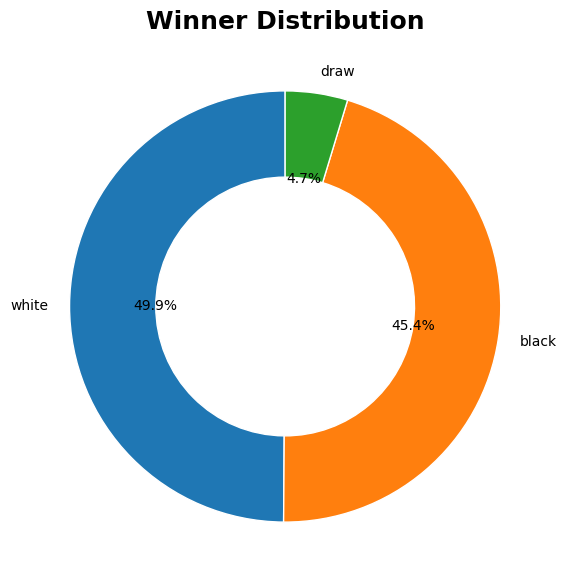

In [51]:
winner_counts = df["winner"].value_counts()   #Count the number of games won by each winner category (White, Black, Draw)

plt.figure(figsize=(7,7))

plt.pie(      # Create a donut chart to show the percentage distribution of game winners
    winner_counts,
    labels=winner_counts.index,
    autopct="%1.1f%%",
    startangle=90,
    wedgeprops=dict(width=0.4, edgecolor="white")
)

plt.title("Winner Distribution",
          fontsize=18,
          fontweight="bold")

plt.show()

# **Chart 9: Winner Distribution**

A donut chart provides a simple and visually appealing way to compare the percentage of White wins, Black wins, and Draws.

**Insights Found**

White wins represent the largest share of total games.
Black wins are slightly lower, while draws account for the smallest percentage.
The chart clearly highlights the overall outcome distribution.

**Business Impact**

Positive: Helps evaluate game balance and identify whether one side consistently performs better than the other.

Negative: A large imbalance in winning percentages may indicate the need to improve player guidance or opening preparation for Black.

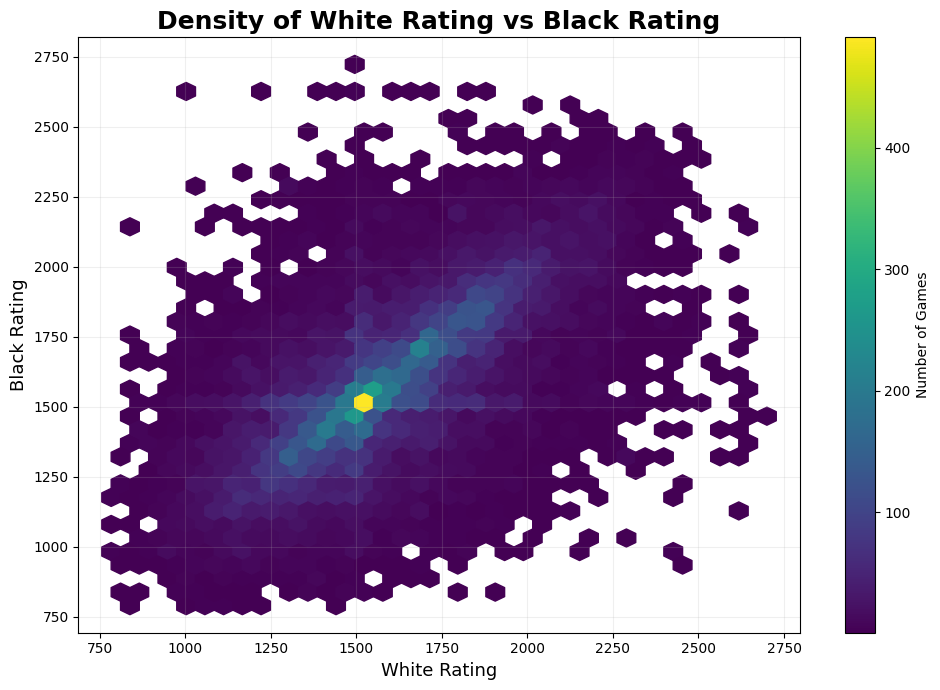

In [52]:
plt.figure(figsize=(10,7))

plt.hexbin(    # Create a hexbin plot to visualize the density of games
# based on White and Black player ratings
    df["white_rating"],
    df["black_rating"],
    gridsize=35,
    cmap="viridis",
    mincnt=1
)

plt.colorbar(label="Number of Games")

plt.title("Density of White Rating vs Black Rating",
          fontsize=18,
          fontweight="bold")

plt.xlabel("White Rating", fontsize=13)
plt.ylabel("Black Rating", fontsize=13)

plt.grid(alpha=0.2)

plt.tight_layout()
plt.show()

# **Chart 10: Density of White Rating vs Black Rating**

A Hexbin plot is ideal for large datasets because it shows the density of games without the overlap that occurs in scatter plots.

**Insights Found**

Most games occur between players with similar ratings.
Dense regions indicate that matchmaking generally pairs players of comparable skill levels.
Very few games involve players with extremely different ratings.

**Business Impact**

Positive: Confirms that the matchmaking system is effective in creating balanced and competitive games.

Negative: Games involving large rating differences may result in one-sided matches, reducing player satisfaction and engagement.

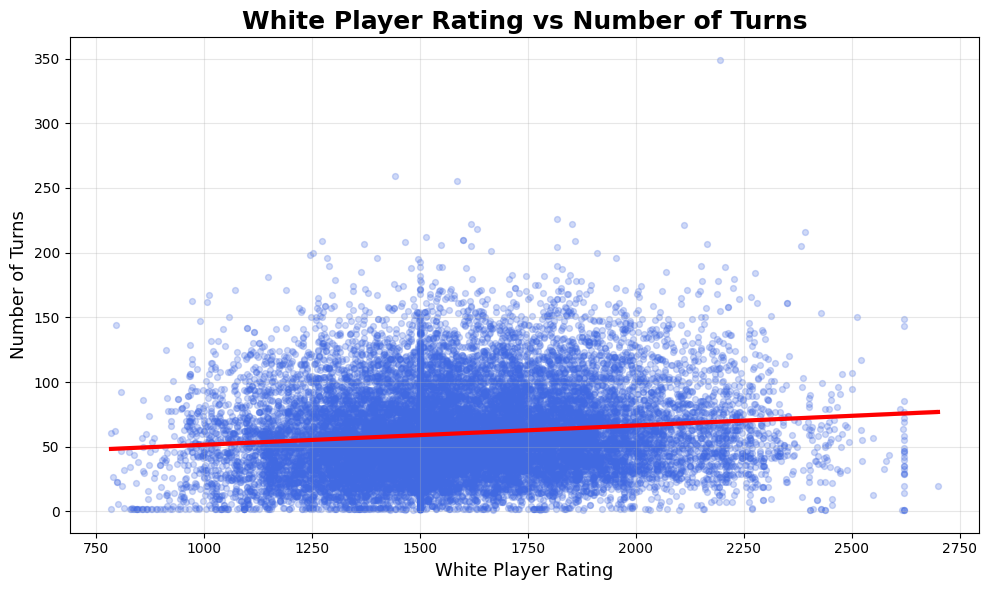

In [47]:
plt.figure(figsize=(10,6))

sns.regplot(  # Create a regression plot to visualize the relationship between
# White player rating and the number of turns in a game
    data=df,
    x="white_rating",
    y="turns",
    scatter_kws={
        "alpha":0.25,
        "s":18,
        "color":"royalblue"
    },
    line_kws={
        "color":"red",
        "linewidth":3
    }
)

plt.title("White Player Rating vs Number of Turns",
          fontsize=18,
          fontweight="bold")

plt.xlabel("White Player Rating", fontsize=13)
plt.ylabel("Number of Turns", fontsize=13)

plt.grid(alpha=0.3)

plt.tight_layout()
plt.show()

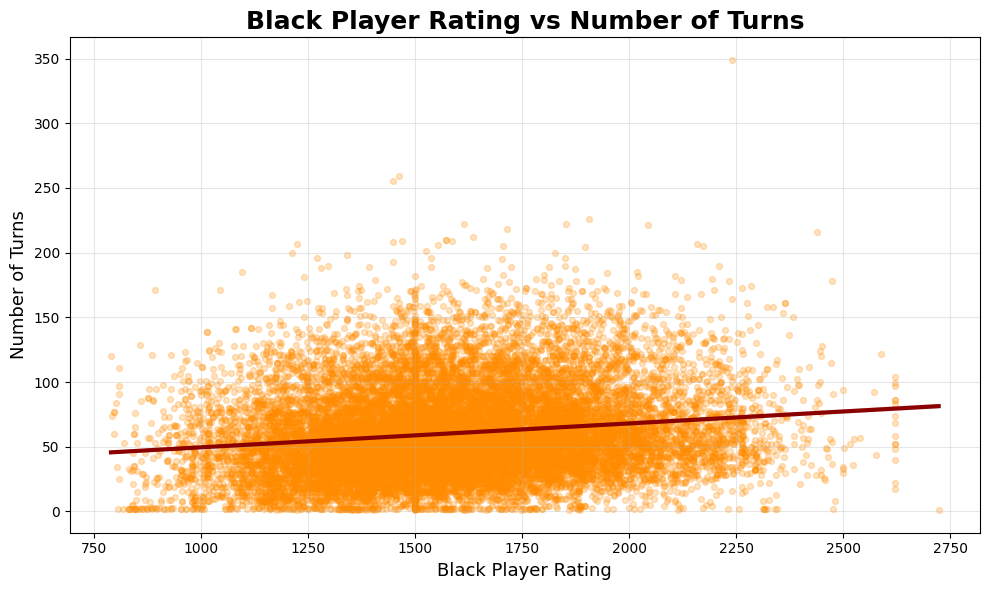

In [48]:
plt.figure(figsize=(10,6))

sns.regplot(
    data=df,
    x="black_rating",
    y="turns",
    scatter_kws={
        "alpha":0.25,
        "s":18,
        "color":"darkorange"
    },
    line_kws={
        "color":"darkred",
        "linewidth":3
    }
)

plt.title("Black Player Rating vs Number of Turns",
          fontsize=18,
          fontweight="bold")

plt.xlabel("Black Player Rating", fontsize=13)
plt.ylabel("Number of Turns", fontsize=13)

plt.grid(alpha=0.3)

plt.tight_layout()
plt.show()

# **Charts 11 & 12: White Rating vs Number of Turns and Black Rating vs Number of Turns**

These regression plots are used to analyze whether a player's rating (White or Black) has any relationship with the number of turns played in a game. They help identify if stronger players tend to play longer or shorter games.

**Insights Found**

Most games involve players with intermediate ratings.
Game length is distributed across all rating levels, showing no strong linear relationship between rating and the number of turns.
The regression lines indicate that player rating alone is not a major factor determining game duration; factors such as opening choice, playing style, and game strategy also influence the number of turns.

**Business Impact**

Positive:

Helps evaluate whether player experience influences game duration.
Can be used to improve coaching strategies by identifying gameplay patterns across different skill levels.
Assists platform developers in understanding player engagement across various rating groups.

Negative:

If lower-rated players consistently finish games in fewer turns, it may indicate frequent mistakes, early resignations, or mismatched opponents.
Since rating has only a weak relationship with game length, relying solely on player rating for matchmaking or game analysis may not accurately reflect the quality or competitiveness of a match.

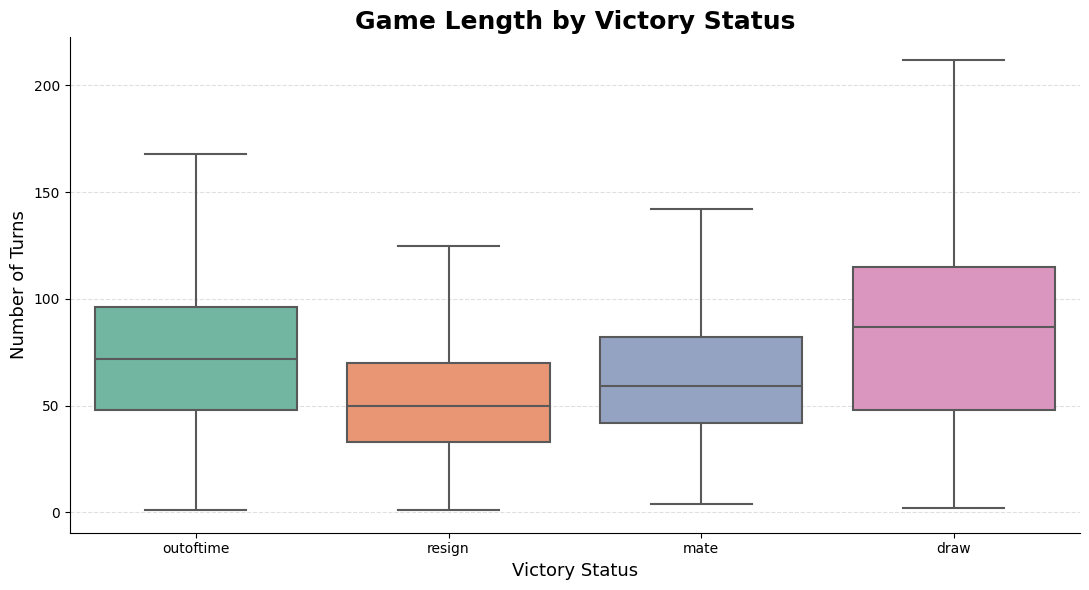

In [ ]:
plt.figure(figsize=(11,6))

ax = sns.boxplot(
    data=df,
    x="victory_status",
    y="turns",
    hue="victory_status",
    palette="Set2",
    legend=False,
    linewidth=1.5,
    showfliers=False
)

plt.title("Game Length by Victory Status", fontsize=18, fontweight="bold")
plt.xlabel("Victory Status", fontsize=13)
plt.ylabel("Number of Turns", fontsize=13)

plt.grid(axis="y", linestyle="--", alpha=0.4)
sns.despine()

plt.tight_layout()
plt.show()

# **Chart 13: Game Length by Victory Status**

This box plot compares the distribution of game lengths for different victory statuses such as checkmate, resignation, timeout, and draw.

**Insights Found**

Different victory statuses have different median game lengths.
Games ending in checkmate generally last longer than games ending by resignation.
The spread of turns varies across victory types.

**Business Impact**

Positive: Helps organizers and developers understand how different game endings affect player behavior and game duration.

Negative: A high number of short resignation games may reduce player engagement and learning opportunities.

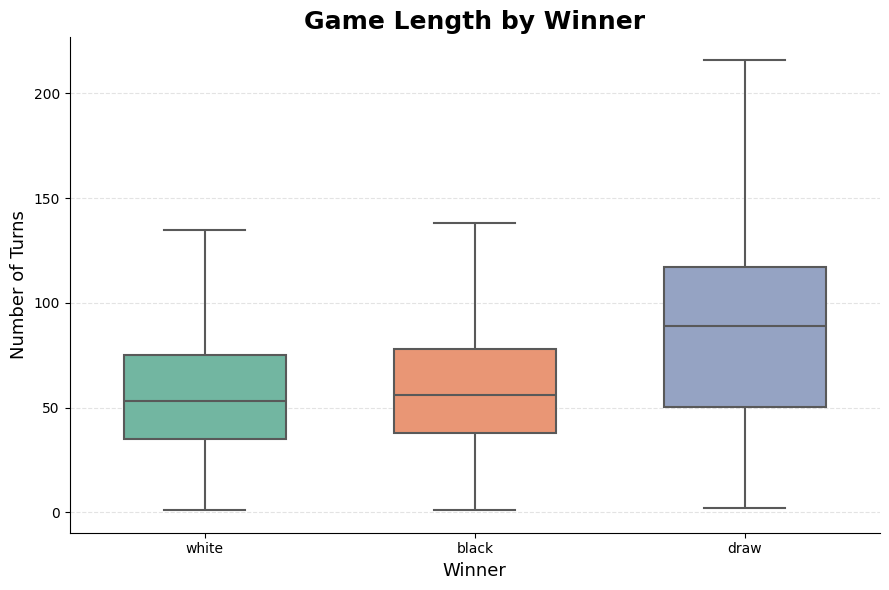

In [ ]:
plt.figure(figsize=(9,6))

ax = sns.boxplot(
    data=df,
    x="winner",
    y="turns",
    hue="winner",
    palette="Set2",
    legend=False,
    width=0.6,
    linewidth=1.5,
    showfliers=False
)

plt.title("Game Length by Winner",
          fontsize=18,
          fontweight="bold")

plt.xlabel("Winner", fontsize=13)
plt.ylabel("Number of Turns", fontsize=13)

plt.grid(axis="y", linestyle="--", alpha=0.35)
sns.despine()

plt.tight_layout()
plt.show()

# **Chart 14: Game Length by Winner**

This chart compares the distribution of game lengths based on the winning side.

**Insights Found**

White wins, Black wins, and Draws have different distributions of game length.
Median turns vary slightly between winners.
Some game outcomes are associated with longer matches.

**Business Impact**

Positive: Helps analyze whether one side generally wins after longer strategic games, supporting coaching and performance analysis.

Negative: If one side consistently wins in much shorter games, it may indicate an imbalance in player preparation or opening strategies.

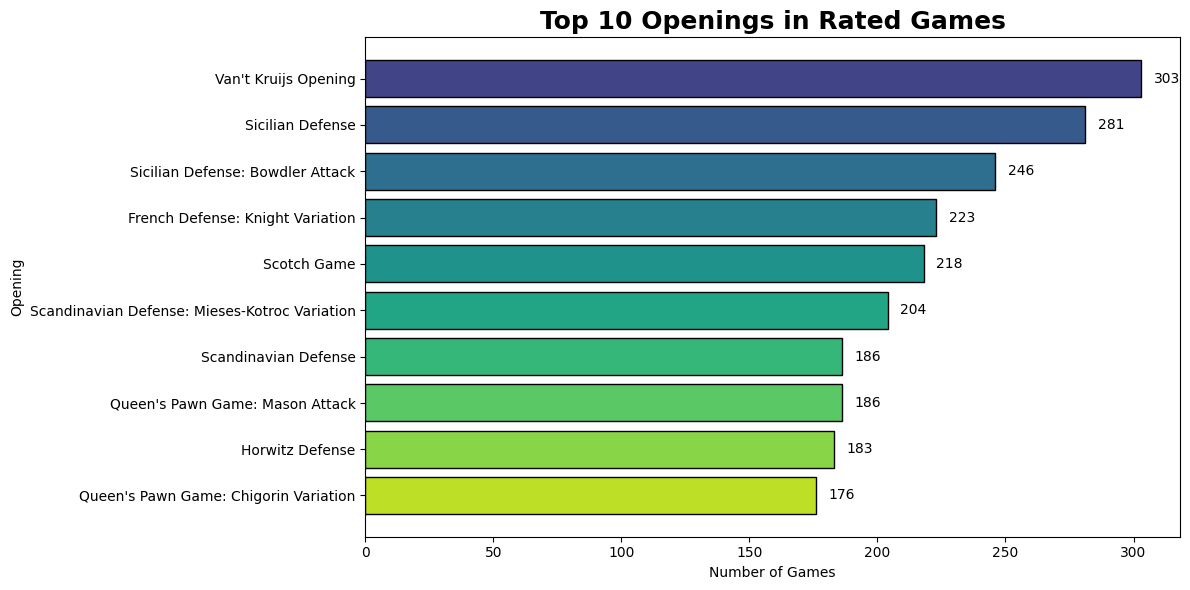

In [ ]:
rated = df[df["rated"] == True]  #Filter the dataset to include only rated chess games

top = rated["opening_name"].value_counts().head(10) # Count the frequency of each opening and select the top 10 most played openings

plt.figure(figsize=(12,6))

colors = plt.cm.viridis(np.linspace(0.2,0.9,len(top)))

bars = plt.barh(
    top.index,
    top.values,
    color=colors,
    edgecolor="black"
)

plt.gca().invert_yaxis() # Count the frequency of each opening and select the top 10 most played openings

plt.title("Top 10 Openings in Rated Games",
          fontsize=18,
          fontweight="bold")

plt.xlabel("Number of Games")
plt.ylabel("Opening")

for bar in bars:
    plt.text(
        bar.get_width()+5,
        bar.get_y()+bar.get_height()/2,
        int(bar.get_width()),
        va="center"
    )

plt.tight_layout()
plt.show()

# **Chart 15: Top 10 Openings in Rated Games**

This chart identifies the most frequently played openings specifically in rated games, highlighting strategies preferred in competitive play.

**Insights Found**

Competitive players rely heavily on a few well-established openings.
Certain openings dominate rated games, indicating their effectiveness and popularity.
Opening selection is less diverse in competitive games than expected.

**Business Impact**

Positive: Chess platforms can recommend training material and opening courses focused on the most commonly played competitive openings.

Negative: Heavy dependence on a limited number of openings may reduce creativity and make games more predictable.

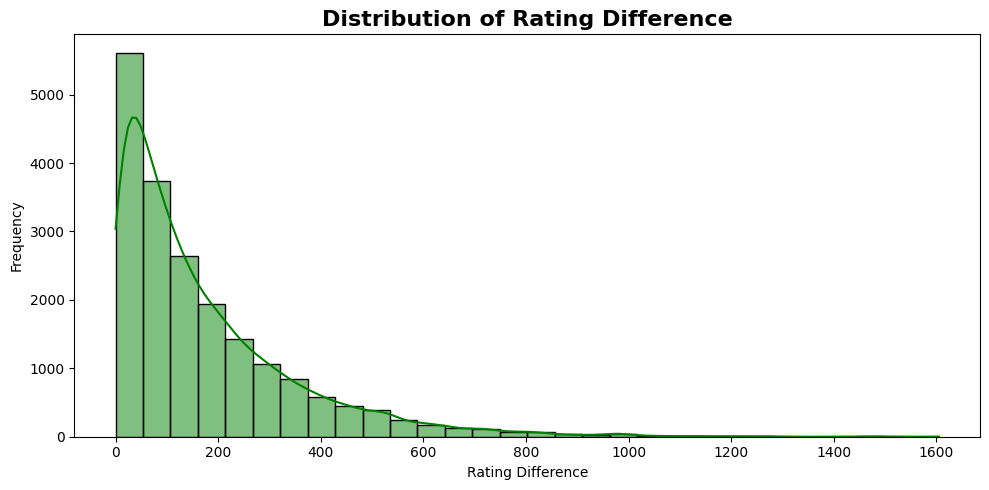

In [ ]:
df['rating_diff'] = abs(df['white_rating'] - df['black_rating'])

plt.figure(figsize=(10,5))

sns.histplot(
    df['rating_diff'],
    bins=30,
    kde=True,
    color='green'
)

plt.title("Distribution of Rating Difference", fontsize=16, weight='bold')
plt.xlabel("Rating Difference")
plt.ylabel("Frequency")

plt.tight_layout()
plt.show()

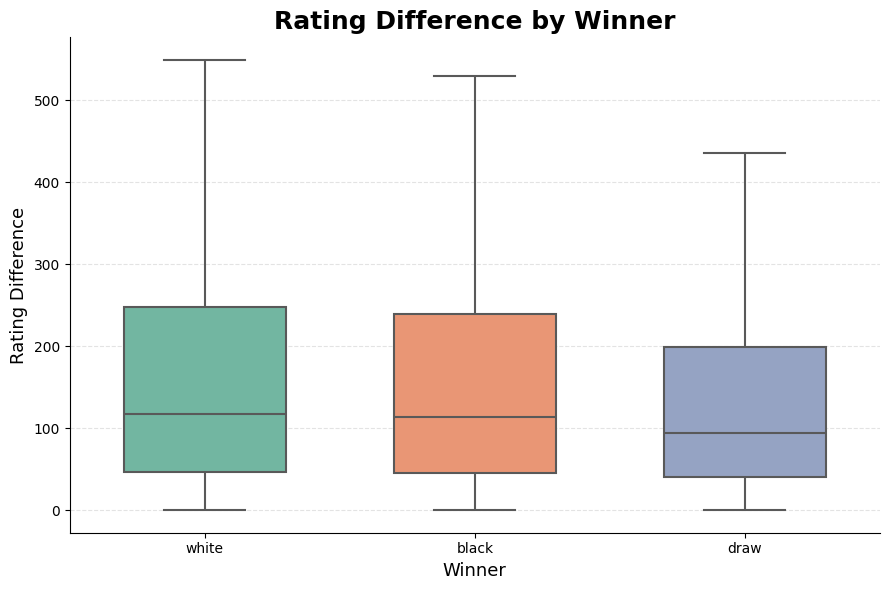

In [ ]:
plt.figure(figsize=(9,6))

ax = sns.boxplot(
    data=df,
    x="winner",
    y="rating_diff",
    hue="winner",          # Removes Seaborn warning
    palette="Set2",
    legend=False,
    width=0.6,
    linewidth=1.5,
    showfliers=False
)

plt.title("Rating Difference by Winner",
          fontsize=18,
          fontweight="bold")

plt.xlabel("Winner", fontsize=13)
plt.ylabel("Rating Difference", fontsize=13)

plt.grid(axis="y", linestyle="--", alpha=0.35)
sns.despine()

plt.tight_layout()
plt.show()

# **Chart 16: Rating Difference by Winner**

This box plot compares the rating difference between players across different game outcomes (White win, Black win, and Draw). It helps analyze whether differences in player skill influence the final result of a chess game.

**Insights Found**

Most games are played between players with relatively small rating differences.
Draws are more common when both players have similar ratings.
Larger rating differences generally lead to decisive results (White or Black wins).
The spread of rating differences varies across different game outcomes.

**Business Impact**

Positive:

Helps improve matchmaking by encouraging games between players of similar skill levels.
Provides insights into how rating differences affect game competitiveness.
Assists tournament organizers in creating balanced pairings.

Negative:

Large rating mismatches may result in one-sided games, reducing player satisfaction.
Frequent mismatches can discourage lower-rated players and negatively affect user retention.

<Figure size 1000x600 with 0 Axes>

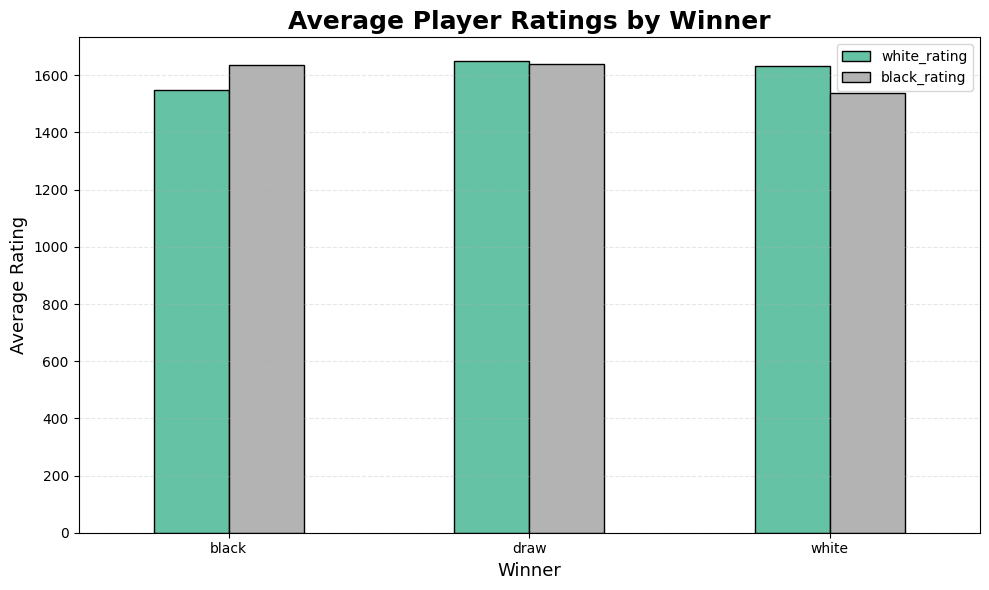

In [39]:
plt.figure(figsize=(10,6))

avg_rating = df.groupby("winner")[["white_rating","black_rating"]].mean()

avg_rating.plot(
    kind="bar",
    figsize=(10,6),
    colormap="Set2",
    edgecolor="black"
)

plt.title("Average Player Ratings by Winner",
          fontsize=18,
          fontweight="bold")

plt.xlabel("Winner", fontsize=13)
plt.ylabel("Average Rating", fontsize=13)

plt.xticks(rotation=0)

plt.grid(axis="y", linestyle="--", alpha=0.3)

plt.tight_layout()
plt.show()

# **Chart 17: Average Player Rating by Winner**

To compare the average ratings of players for different game outcomes and understand how player skill influences the winner.

**Insights Found**

Winners generally have slightly higher average ratings.
Draws usually occur between players with similar ratings.
Player rating has a noticeable influence on game outcomes.

**Business Impact**

Positive: Helps evaluate matchmaking quality and supports fair rating-based tournaments.

Negative: Large rating differences may lead to predictable results and reduce game competitiveness.

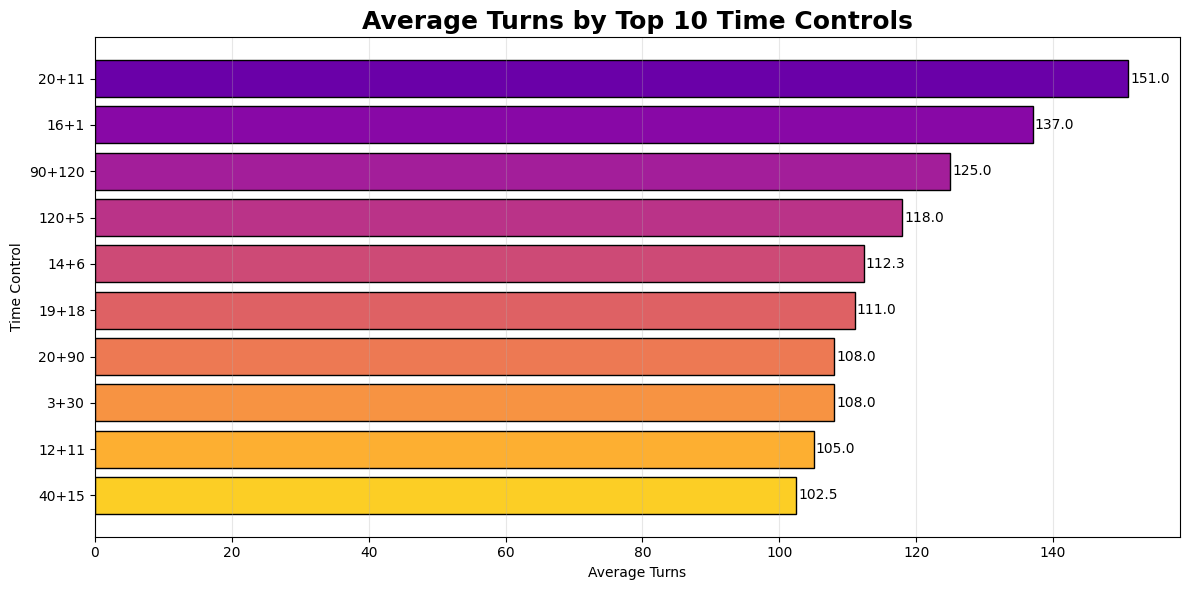

In [40]:
plt.figure(figsize=(12,6))

top = (
    df.groupby("increment_code")["turns"]
      .mean()
      .sort_values(ascending=False)
      .head(10)
)

colors = plt.cm.plasma(np.linspace(0.2,0.9,len(top)))

bars = plt.barh(
    top.index,
    top.values,
    color=colors,
    edgecolor="black"
)

plt.gca().invert_yaxis()

plt.title("Average Turns by Top 10 Time Controls",
          fontsize=18,
          fontweight="bold")

plt.xlabel("Average Turns")
plt.ylabel("Time Control")

for bar in bars:
    plt.text(
        bar.get_width()+0.3,
        bar.get_y()+bar.get_height()/2,
        f"{bar.get_width():.1f}",
        va="center"
    )

plt.grid(axis="x", alpha=0.3)

plt.tight_layout()
plt.show()

# **Chart 18: Average Turns by Top 10 Time Controls**

To compare the average number of turns played across the top 10 most popular time controls and understand how time limits affect game duration.

**Insights Found**

Longer time controls generally result in games with more turns.
Faster time controls tend to produce shorter games due to increased time pressure.
Game duration varies noticeably across different time formats.

**Business Impact**

Positive: Helps tournament organizers and chess platforms choose time controls that match player preferences and improve the gaming experience.

Negative: Extremely short time controls may lead to rushed moves, lower game quality, and reduced player satisfaction.

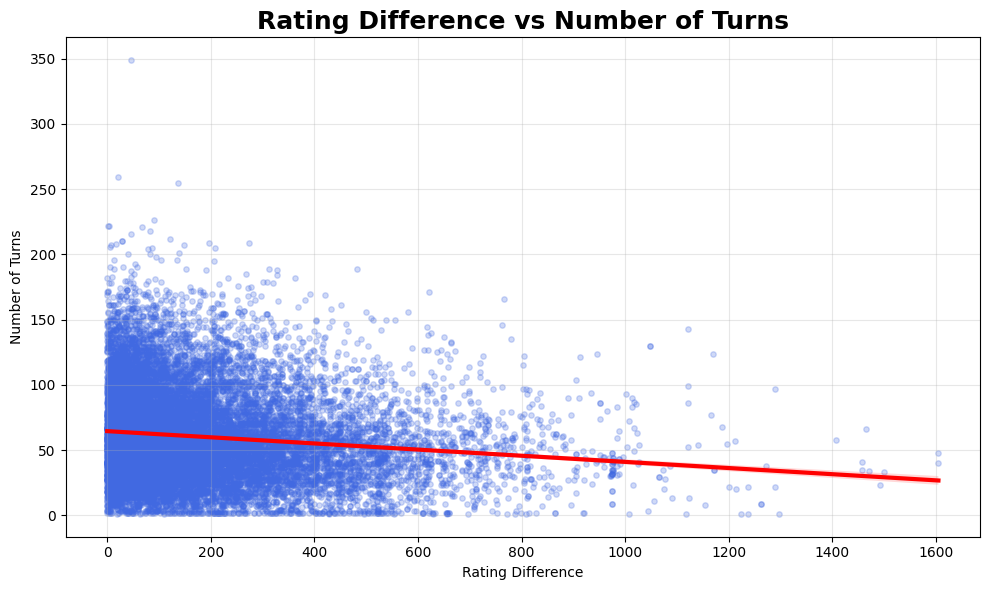

In [41]:
df["rating_diff"] = abs(df["white_rating"] - df["black_rating"])
plt.figure(figsize=(10,6))

sns.regplot(
    data=df,
    x="rating_diff",
    y="turns",
    scatter_kws={
        "alpha":0.25,
        "s":15,
        "color":"royalblue"
    },
    line_kws={
        "color":"red",
        "linewidth":3
    }
)

plt.title("Rating Difference vs Number of Turns",
          fontsize=18,
          fontweight="bold")

plt.xlabel("Rating Difference")
plt.ylabel("Number of Turns")

plt.grid(alpha=0.3)

plt.tight_layout()
plt.show()

# **Chart 19: Rating Difference vs Number of Turns**
To analyze whether the difference in player ratings affects the duration of a chess game.

**Insights Found**

Games between players with similar ratings generally last longer.
Larger rating differences often result in shorter games, as stronger players tend to win more quickly.
The relationship indicates that balanced matches are usually more competitive.

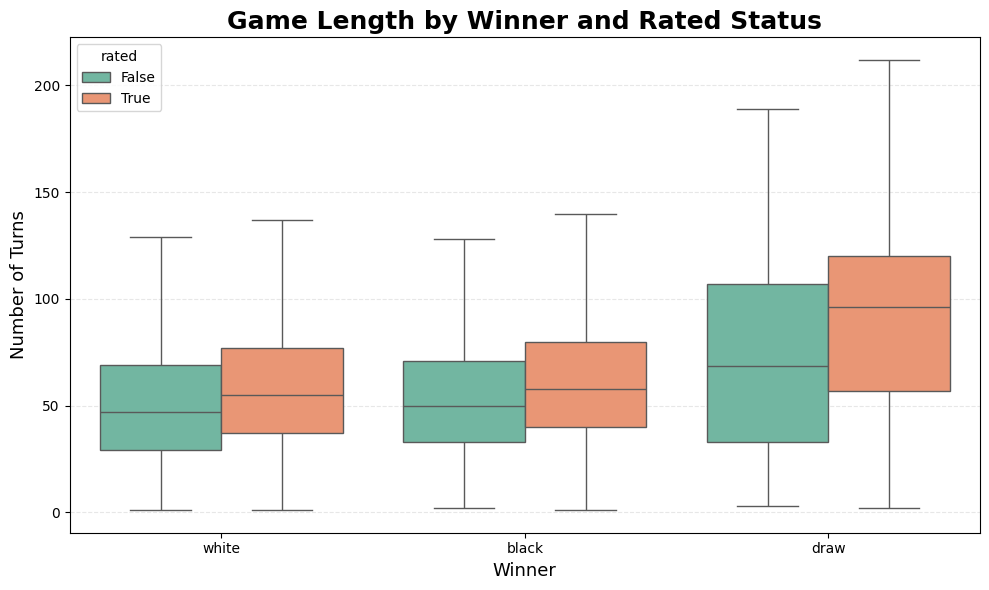

In [53]:
plt.figure(figsize=(10,6))

sns.boxplot(
    data=df,
    x="winner",
    y="turns",
    hue="rated",
    palette="Set2",
    showfliers=False
)

plt.title(
    "Game Length by Winner and Rated Status",
    fontsize=18,
    fontweight="bold"
)

plt.xlabel("Winner", fontsize=13)
plt.ylabel("Number of Turns", fontsize=13)

plt.grid(axis="y", linestyle="--", alpha=0.3)

plt.tight_layout()
plt.show()

# **Chart 20 : Game Length by Winner and Rated Status**

This box plot compares the number of turns based on the winner while also distinguishing between rated and casual games. It helps analyze how both game outcome and game type influence game duration.

**Insights Found**

Rated games generally have more turns than casual games.
Drawn games usually last longer regardless of game type.
Winning patterns differ slightly between rated and casual matches.

**Business Impact**

Positive: Helps tournament organizers and chess platforms understand player behavior in competitive and casual games, allowing better tournament design and matchmaking.

Negative: If casual games consistently end much earlier than rated games, it may indicate lower player engagement or frequent early resignations.


# **Conclusion**

The Exploratory Data Analysis (EDA) of the Lichess Chess Games dataset provided useful insights into player behavior, game outcomes, and gameplay patterns. Most players belong to the intermediate rating range, with White winning slightly more games than Black. Popular openings and time controls dominate the majority of matches, reflecting common player preferences.

The analysis also showed that players are generally matched against opponents with similar ratings, leading to balanced and competitive games. While player rating has some influence on game outcomes, factors such as opening strategy, time control, and player decisions also play an important role in determining game length and results.

Overall, the insights gained from this analysis can help improve matchmaking, tournament planning, player training, and user experience, making the platform more engaging and competitive.